# Shortest Path Between Wikipedia Articles

This notebook demonstrates the **Wikipedia game**: find the minimum number of clicks (hyperlink hops) needed to navigate from one article to another.

The system uses **BFS** for this task because BFS guarantees it visits nodes in order of increasing distance from the start — so the first time it reaches the target, that path is definitively the shortest.

In [6]:
import sys
sys.path.insert(0, "..")

from src import BFSFrontier, WikiScraper, WikiExplorer

## Find the shortest path

In [7]:
START  = "Cat"
TARGET = "Science"

# max_pages guide:
#   closely related topics (e.g. Data science → Deep learning) : 100-200 is fine
#   loosely related topics (e.g. Cat → Science)                : 300-500
#   very distant topics   (e.g. Cat → Ancient Rome)            : 500-1000 (slow, ~5 min)
explorer = WikiExplorer(
    frontier  = BFSFrontier(),
    scraper   = WikiScraper(delay=0.3),
    verbose   = True,
)

path = explorer.shortest_path(START, TARGET, max_pages=400)

[BFS shortest |    1/400] Cat
[BFS shortest |    2/400] Felidae
[BFS shortest |    3/400] Cat (disambiguation)
[BFS shortest |    4/400] Cats (disambiguation)
[BFS shortest |    5/400] Megaannum


In [8]:
if path:
    print(f"\nShortest path ({len(path) - 1} hops):")
    for i, page in enumerate(path):
        prefix = "START → " if i == 0 else ("TARGET " if i == len(path)-1 else f"  [{i}]   ")
        print(f"{prefix} {page}")
else:
    print("No path found within the page limit.")


Shortest path (2 hops):
START →  Cat
  [1]    Megaannum
TARGET  Science


## Try different pairs

Edit the cell below and re-run to explore different start/target combinations.

In [9]:
PAIRS = [
    # (start, target, max_pages)
    # Close topics — fast (< 30 s)
    ("Data science",   "Deep learning",  200),
    ("Data science",   "Statistics",     200),
    # Medium distance — moderate (< 2 min)
    ("Data science",   "Dinosaur",       500),
    ("Machine learning", "Ancient Rome", 500),
]

scraper = WikiScraper(delay=0.3)

for start, target, limit in PAIRS:
    exp = WikiExplorer(BFSFrontier(), scraper=scraper, verbose=False)
    p = exp.shortest_path(start, target, max_pages=limit)
    if p:
        print(f"  {start!r:40s} → {target!r}  ({len(p)-1} hops)")
        print("  Path:", " → ".join(p))
    else:
        print(f"  {start!r} → {target!r}  NOT FOUND within {limit} pages")
    print()

  'Data science'                           → 'Deep learning'  (2 hops)
  Path: Data science → Machine learning → Deep learning

  'Data science'                           → 'Statistics'  (1 hops)
  Path: Data science → Statistics

  'Data science' → 'Dinosaur'  NOT FOUND within 500 pages

  'Machine learning'                       → 'Ancient Rome'  (2 hops)
  Path: Machine learning → Insurance → Ancient Rome



## Visualise the path as a linear chain

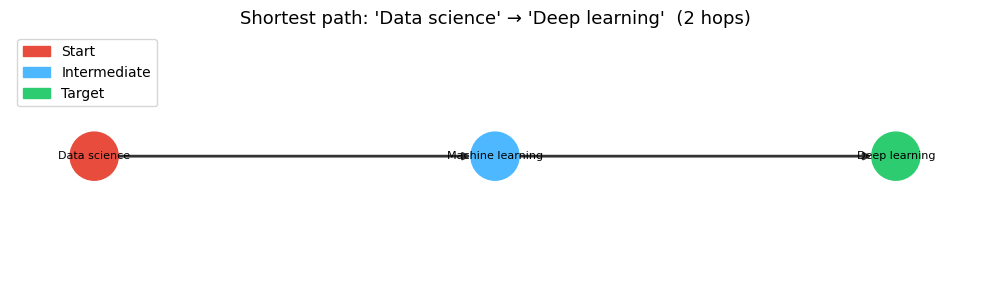

In [10]:
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

START  = "Data science"
TARGET = "Deep learning"

exp   = WikiExplorer(BFSFrontier(), scraper=WikiScraper(delay=0.3), verbose=False)
path  = exp.shortest_path(START, TARGET, max_pages=200)

if path:
    G = nx.DiGraph()
    for i in range(len(path) - 1):
        G.add_edge(path[i], path[i + 1])

    fig, ax = plt.subplots(figsize=(max(10, len(path) * 2), 3))
    pos = {page: (i, 0) for i, page in enumerate(path)}

    colors = []
    for n in G.nodes():
        if n == START:
            colors.append("#e74c3c")
        elif n == TARGET:
            colors.append("#2ecc71")
        else:
            colors.append("#4DB8FF")

    nx.draw_networkx(
        G, pos, ax=ax,
        node_color=colors,
        node_size=1200,
        font_size=8,
        arrows=True,
        edge_color="#333",
        width=2,
    )
    start_patch  = mpatches.Patch(color="#e74c3c", label="Start")
    target_patch = mpatches.Patch(color="#2ecc71", label="Target")
    mid_patch    = mpatches.Patch(color="#4DB8FF", label="Intermediate")
    ax.legend(handles=[start_patch, mid_patch, target_patch], loc="upper left")
    ax.set_title(f"Shortest path: '{START}' → '{TARGET}'  ({len(path)-1} hops)", fontsize=13)
    ax.axis("off")
    plt.tight_layout()
    plt.savefig("shortest_path.png", dpi=150)
    plt.show()
else:
    print("Path not found — try increasing max_pages or choosing closer topics.")

## Why BFS guarantees the shortest path

BFS explores nodes **layer by layer**. All nodes at depth *d* are fully explored before any node at depth *d+1* is touched.

```
Start
  ├── depth 1 pages  (all direct links from Start)
  │     ├── depth 2 pages
  │     │     └── ...
  │     └── ...
  └── ...
```

The moment the target is encountered, we know it's at the minimum possible depth — no shorter path can exist, because we've already exhausted all shallower layers.

DFS makes no such guarantee: it might find *a* path, but not necessarily the *shortest* one.